# 01 — Black (1976) Formula + Implied Volatility

Reference: Hagan, Kumar, Lesniewski, Woodward (2002), *Managing Smile Risk*, eq. (2.4).

**Black (1976) call / put on a forward:**
$$ V_{\text{call}} = D(0,T)\,[F\,N(d_1) - K\,N(d_2)] $$
$$ V_{\text{put}}  = D(0,T)\,[K\,N(-d_2) - F\,N(-d_1)] $$
$$ d_{1,2} = \frac{\ln(F/K) \pm \tfrac12 \sigma^2 T}{\sigma \sqrt{T}},\quad D(0,T) = e^{-rT}. $$

The SABR model in later notebooks produces $\sigma_{SABR}$, which is then fed into this formula to obtain an option price.

In [1]:
# allow importing from ../src
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (7, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})


In [2]:
from src.black import (
    black_call, black_put, black_price, black_vega,
    implied_vol_from_price,
)

F, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20
C = black_call(F, K, sigma, T, r)
P = black_put (F, K, sigma, T, r)
print(f'Call = {C:.6f}')
print(f'Put  = {P:.6f}')

Call = 7.577082
Put  = 7.577082


### Test 1 — Put-call parity
$$ C - P = D(0,T)\,(F - K) $$

In [3]:
lhs = C - P
rhs = np.exp(-r*T) * (F - K)
print(f'C - P       = {lhs: .8f}')
print(f'D(F - K)    = {rhs: .8f}')
print(f'difference  = {abs(lhs - rhs):.2e}')
assert abs(lhs - rhs) < 1e-10, 'put-call parity violated'

C - P       =  0.00000000
D(F - K)    =  0.00000000
difference  = 0.00e+00


### Test 2 — Implied-volatility round-trip
Input $\sigma \to$ price $\to$ invert $\to$ recovered $\sigma$.

In [4]:
sigmas_in = [0.05, 0.10, 0.20, 0.30, 0.50, 0.80]
print(f'{"sigma_in":>10} {"price":>10} {"sigma_out":>12} {"err":>12}')
for s in sigmas_in:
    px = black_call(F, K, s, T, r)
    s_hat = implied_vol_from_price(px, F, K, T, r, 'call')
    print(f'{s:>10.4f} {px:>10.4f} {s_hat:>12.8f} {abs(s-s_hat):>12.2e}')

  sigma_in      price    sigma_out          err
    0.0500     1.8972   0.05000000     1.66e-09
    0.1000     3.7933   0.10000000     5.74e-14
    0.2000     7.5771   0.20000000     2.93e-11
    0.3000    11.3420   0.30000000     1.75e-09
    0.5000    18.7785   0.50000000     2.03e-12
    0.8000    29.5683   0.80000000     2.36e-09


### Test 3 — Round-trip across strikes (ITM / ATM / OTM)

In [5]:
Ks = np.linspace(70, 130, 13)
sigma = 0.25
errs = []
for K_ in Ks:
    px = black_call(F, K_, sigma, T, r)
    s_hat = implied_vol_from_price(px, F, K_, T, r, 'call')
    errs.append(abs(sigma - s_hat))
print(f'max inversion error across strikes = {max(errs):.2e}')

max inversion error across strikes = 2.28e-09


### Test 4 — Price and vega versus $\sigma$

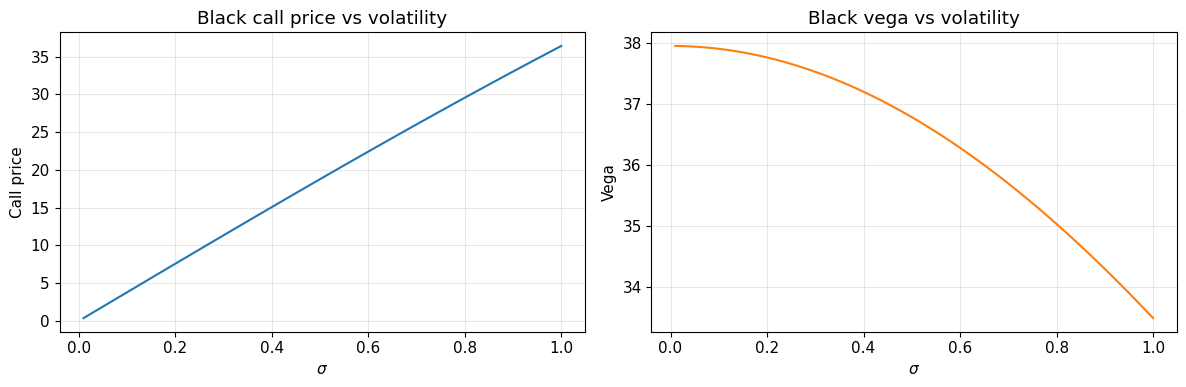

In [6]:
sigmas = np.linspace(0.01, 1.00, 100)
prices = black_call(F, K, sigmas, T, r)
vegas  = black_vega(F, K, sigmas, T, r)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sigmas, prices); ax[0].set_xlabel(r'$\sigma$'); ax[0].set_ylabel('Call price')
ax[0].set_title('Black call price vs volatility')
ax[1].plot(sigmas, vegas, color='C1'); ax[1].set_xlabel(r'$\sigma$'); ax[1].set_ylabel('Vega')
ax[1].set_title('Black vega vs volatility')
plt.tight_layout(); plt.show()

### Summary
* Black call / put implemented against Hagan (2.4).
* Put-call parity holds to machine precision.
* Implied-volatility inverter (Brent on $[10^{-6}, 5]$) recovers $\sigma$ to $<10^{-8}$.
* These routines will be called from Module 4 (calibration) and Module 5 (SABR vs BS comparison).